In [2]:
import pandas as pd
from pathlib import Path
import networkx as nx
import random
import subprocess
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
import math
import numpy as np
from numpy.linalg import inv

current_path = '/home/edu/Area_de_Trabalho/Projs/links'

In [3]:
class heurist_metric:
    def __init__(self):
        pass

    def calculate_metric():
        pass


class Katz_metric(heurist_metric):
    def __init__(self):
        super().__init__()
        pass
   
    def calculate_metric(self,train_graph):

        Bi_netw = nx.Graph()
        Bi_netw.add_nodes_from(train_graph.left_nodes.unique().tolist(), bipartite=0)
        Bi_netw.add_nodes_from(train_graph.right_nodes.unique().tolist(), bipartite=1)
        Bi_netw.add_edges_from(train_graph[["left_nodes","right_nodes"]].drop_duplicates().values.tolist())

        adj_matrix = nx.adjacency_matrix(Bi_netw)
        beta = 0.1
        n = adj_matrix.shape[0]
        identity = np.eye(n)

        similarity = np.linalg.inv(identity - beta * adj_matrix) - identity
        
        nodes = list(Bi_netw.nodes)
        formated_return = []
        for i in range(n):
            for j in range(i+1,n):
                formated_return.append([nodes[i],nodes[j],similarity[i][j]])

        formated_return = pd.DataFrame(formated_return)    
        formated_return.columns = ["left_nodes","right_nodes","pred"]

        return formated_return


class F3_metric(heurist_metric):
    def __init__(self):
        super().__init__()
        pass
   
    def calculate_metric(self,train_graph):

        train_graph["weight"] = 1
        train_graph.to_csv(f"{current_path}/data/kpisti-L3-a163e9f/graph.txt",header=None,sep=" ",index=False)
        subprocess.run(f"/home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/teste.out /home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/graph.txt", shell=True)
        subprocess.run(f"mv /home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/L3_predictions_graph.txt.dat /home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/L3_predictions_graph.txt", shell=True)
        result = pd.read_csv(f"{current_path}/data/kpisti-L3-a163e9f/L3_predictions_graph.txt",sep="\t",header=None)
        result.columns = ["left_nodes","right_nodes","pred"]
        return result

class Bi_Graph:
    def __init__(self,left_nodes,right_nodes):
        self.df = pd.DataFrame({"left_nodes":left_nodes,
                               "right_nodes":right_nodes}) 
        self.clean_graph()
    
    def clean_graph(self):
        self.df = self.df.groupby("left_nodes").filter(lambda x: len(x) > 10)

    
    def get_train_test_nodes(self,random_state = 42):
        selected_nodes = random.sample(self.df.left_nodes.unique().tolist(),k=512)
        self.df = self.df[self.df["left_nodes"].isin(selected_nodes)]


        test_graph = self.df.groupby("left_nodes").apply(lambda x : x.sample(n=3,random_state=random_state)).reset_index(drop=True)
        test_pairs = test_graph[['left_nodes','right_nodes']]
        train_graph = self.df.merge(test_pairs, on=['left_nodes','right_nodes'], how='left', indicator=True)
        train_graph = train_graph[train_graph['_merge'] == 'left_only'].drop(columns=['_merge'])

        test_graph = test_graph[["left_nodes","right_nodes"]]
        test_graph["Label"] = True

        negative_links = [[i,j] for i in pd.Series(self.df.left_nodes.unique()).sample(50,random_state=random_state) for j in pd.Series(self.df.right_nodes.unique()).sample(50,random_state=42)]
        negative_links = pd.DataFrame(negative_links,columns=["left_nodes","right_nodes"])
        negative_links = negative_links.merge(self.df,on=['left_nodes','right_nodes'], how='left', indicator=True)
        negative_links = negative_links[negative_links['_merge'] == 'left_only'].drop(columns=['_merge'])
        negative_links = negative_links[['left_nodes','right_nodes']]
        negative_links["Label"] = False

        test_graph = pd.concat([negative_links,test_graph])
        return test_graph,train_graph


class Experiment:
    def __init__(self,graph,metric):
        self.graph = graph
        self.metric = metric

    def exp(self,random_state=42):

        test_graph,train_graph = self.graph.get_train_test_nodes(random_state= random_state)
        predict = self.metric.calculate_metric(train_graph)
        print(predict)
        
        xs,ys = [],[]
        for threshold in range(0,100):
            predict_copy = predict.copy()
            predict_copy["pred"] = predict_copy["pred"].apply(lambda x : x> 0.03*threshold)
            test_graph_2 = test_graph.copy().join(predict_copy.set_index(["left_nodes","right_nodes"]),on=["left_nodes","right_nodes"])

            test_graph_2 = test_graph_2.fillna(False)

            xs.append(precision_score(y_true=test_graph_2.Label.values.tolist(),y_pred=test_graph_2.pred.values.tolist()))
            ys.append(recall_score(y_true=test_graph_2.Label.values.tolist(),y_pred=test_graph_2.pred.values.tolist()))
            
        return xs,ys

In [4]:
import warnings
warnings.filterwarnings('ignore')


aux = []
for j in range(100):
    data = pd.read_csv(f"{current_path}/data/movies/rating.csv",sep = ",")
    f3 = F3_metric()
    graph = Bi_Graph(left_nodes=data.userId,right_nodes=data.movieId)
    exp_teste = Experiment(graph,f3)
    xs,ys = exp_teste.exp(random_state=j)
    box = 0
    for i in range(len(xs)-1):
        box += ((ys[i+1]+ys[i])/2)*(xs[i+1]-xs[i])
    # aux.append(box)
    # print(box)


KeyboardInterrupt: 

In [ ]:
data = pd.read_csv("/home/edu/Area_de_Trabalho/Projs/links/data/movies/testes/grafo_0.csv")
def calculate_metric(train_graph):

        train_graph["weight"] = 1
        train_graph.to_csv(f"{current_path}/data/kpisti-L3-a163e9f/graph.txt",header=None,sep=" ",index=False)
        subprocess.run(f"/home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/teste.out /home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/graph.txt", shell=True)
        subprocess.run(f"mv /home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/L3_predictions_graph.txt.dat /home/edu/Area_de_Trabalho/Projs/links/data/kpisti-L3-a163e9f/L3_predictions_graph.txt", shell=True)
        result = pd.read_csv(f"{current_path}/data/kpisti-L3-a163e9f/L3_predictions_graph.txt",sep="\t",header=None)
        result.columns = ["left_nodes","right_nodes","pred"]
        return result

aux = calculate_metric(data)

         left_nodes  right_nodes        pred
0            138873        18611  184.224000
1            139020        84476  157.847000
2            138811       120666  152.168000
3            138603       120666  142.654000
4            138789        28744  140.869000
...             ...          ...         ...
3861218      145298       107929    0.001882
3861219      145695       107929    0.001882
3861220      145216       107929    0.001882
3861221      184840       107929    0.001882
3861222      170180       107929    0.001882

[3861223 rows x 3 columns]


In [ ]:
f3 = F3_metric()
graph = Bi_Graph(left_nodes=data.userId,right_nodes=data.movieId)

In [ ]:

exp_teste = Experiment(graph,f3)
sim = exp_teste.exp()


/tmp/ipykernel_4646/902773363.py:70: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_graph = self.df.groupby("left_nodes").apply(lambda x : x.sample(n=3,random_state=42)).reset_index(drop=True)
/tmp/ipykernel_4646/902773363.py:105: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_graph_2 = test_graph_2.fillna(False)
/tmp/ipykernel_4646/902773363.py:105: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call

In [53]:
xs,ys = sim[0],sim[1]


In [ ]:
aux = 0
for i in range(len(xs)-1):
    aux += ((ys[i+1]+ys[i])/2)*(xs[i+1]-xs[i])
print(aux)

0.13964093011933423


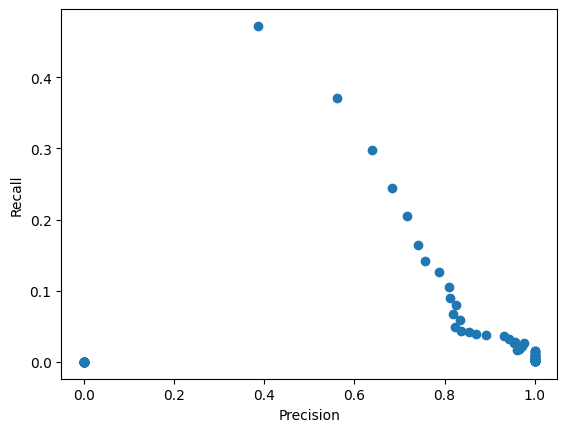

In [51]:
import matplotlib.pyplot as plt

plt.xlabel("Precision")
plt.ylabel("Recall")
plt.scatter(sim[0],sim[1])
plt.show()